# 02 · Generación de escenarios

Este notebook cubre la **sección 2.4** de la práctica: construir el vector aleatorio $\xi = (\xi_{ij})_{(i,j)\in A} \in \mathbb{R}^{110}$ y generar $K$ escenarios a partir de los pools $P_{ij}$ construidos en el notebook anterior.

Para cada escenario $s$ y arco $(i,j)$:

$$\xi_{ij}^{(s)} \sim \widehat{F}_{ij}, \qquad \widehat{F}_{ij} := \text{distribución empírica de } P_{ij}$$

es decir, se selecciona **al azar y con reemplazo** una duración histórica del pool correspondiente. El muestreo es **independiente entre arcos**.

**Entradas:** `data/processed/pools.parquet`, `data/processed/arc_costs.csv`
**Salidas:** `data/processed/scenarios_K50.parquet`, `data/processed/scenarios_K200.parquet` — matrices de $K$ filas $\times$ 110 columnas (una columna por arco), en formato ancho para consumo directo de los modelos de optimización.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROC_DIR = Path("../data/processed")

pools = pd.read_parquet(PROC_DIR / "pools.parquet")     # columnas: i, j, t
arc_costs = pd.read_csv(PROC_DIR / "arc_costs.csv")      # columnas: i, j, median_miles, d_road_km, c_ij, n_trips
sites = pd.read_csv(PROC_DIR / "sites.csv")

print(f"Registros en pools: {len(pools):,}")
print(f"Arcos en arc_costs: {len(arc_costs)}")
pools.head()


Registros en pools: 242,841
Arcos en arc_costs: 110


,i,j,t
0,8,7,9.250000
1,7,4,3.783333
2,1,2,4.166667
3,4,8,11.000000
4,7,0,4.566667


## 1. Lista ordenada de arcos

Fijamos un orden único de los 110 arcos $(i,j) \in A$. Este mismo orden se usará en todos los notebooks siguientes (formulación MILP, L-shaped, etc.), así que **no se debe recalcular ni reordenar** en otro lugar.

In [2]:
node_ids = sites["i"].tolist()  # 0..10
arc_list = [(i, j) for i in node_ids for j in node_ids if i != j]

assert len(arc_list) == 110, f"Se esperaban 110 arcos, hay {len(arc_list)}"
print(f"Total de arcos: {len(arc_list)}")
arc_list[:5], arc_list[-5:]


Total de arcos: 110


([(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)],
 [(10, 5), (10, 6), (10, 7), (10, 8), (10, 9)])

## 2. Diccionario de pools para muestreo rápido

Convertimos `pools` (formato largo) a un diccionario `{(i, j): np.array de duraciones}` para muestrear eficientemente con `np.random.choice`.

In [3]:
pools_dict = {
    (i, j): grp["t"].to_numpy()
    for (i, j), grp in pools.groupby(["i", "j"])
}

# Control de calidad: todos los arcos de arc_list deben tener pool no vacío
missing = [a for a in arc_list if a not in pools_dict]
assert len(missing) == 0, f"Arcos sin pool: {missing}"

sizes = {a: len(pools_dict[a]) for a in arc_list}
print(f"Pool más pequeño: {min(sizes.values())} registros -> arco {min(sizes, key=sizes.get)}")
print(f"Pool más grande:  {max(sizes.values())} registros -> arco {max(sizes, key=sizes.get)}")


Pool más pequeño: 87 registros -> arco (10, 6)
Pool más grande:  8826 registros -> arco (7, 2)


## 3. Función de muestreo de escenarios

Genera una matriz $K \times 110$: cada fila es un escenario $\xi^{(s)}$, cada columna un arco (en el orden fijado en `arc_list`). El muestreo es con reemplazo, independiente entre arcos, y reproducible mediante una semilla.

In [4]:
def generate_scenarios(pools_dict: dict, arc_list: list, K: int, seed: int) -> pd.DataFrame:
    """Genera K escenarios sintéticos de tiempos de viaje.

    Para cada arco (i, j), muestrea K duraciones con reemplazo de su pool empírico,
    de forma independiente entre arcos (independiente también entre escenarios
    dentro de un mismo arco, salvo por compartir la misma semilla global).

    Retorna un DataFrame K x |A| con columnas 'xi_i_j'.
    """
    rng = np.random.default_rng(seed)
    data = {}
    for (i, j) in arc_list:
        pool = pools_dict[(i, j)]
        data[f"xi_{i}_{j}"] = rng.choice(pool, size=K, replace=True)
    return pd.DataFrame(data)


## 4. Generar la muestra de prueba (K = 50)

Se usa para la **prueba de consistencia** entre la formulación extensa MILP y el Integer L-shaped (sección 5.1). Ambas implementaciones deben leer exactamente este mismo archivo.

In [5]:
SEED_K50 = 42

scenarios_K50 = generate_scenarios(pools_dict, arc_list, K=50, seed=SEED_K50)
print(scenarios_K50.shape)
scenarios_K50.head()


(50, 110)


,xi_0_1,xi_0_2,xi_0_3,xi_0_4,xi_0_5,xi_0_6,xi_0_7,xi_0_8,xi_0_9,xi_0_10,...,xi_10_0,xi_10_1,xi_10_2,xi_10_3,xi_10_4,xi_10_5,xi_10_6,xi_10_7,xi_10_8,xi_10_9
0,3.183333,12.300000,18.550000,13.900000,6.350000,23.000000,11.450000,23.400000,29.066667,37.000000,...,14.483333,29.700000,30.900000,30.133333,33.216667,40.066667,9.766667,23.833333,5.533333,5.916667
1,10.866667,14.100000,13.450000,4.466667,13.883333,25.050000,8.583333,13.566667,22.033333,24.916667,...,15.850000,18.816667,19.850000,9.700000,26.433333,22.633333,18.066667,17.183333,8.350000,6.416667
2,12.733333,21.783333,11.466667,12.983333,9.433333,19.866667,3.216667,17.016667,12.933333,25.833333,...,16.933333,34.516667,20.766667,22.233333,22.583333,27.416667,11.883333,18.800000,2.566667,1.016667
3,8.100000,19.516667,11.100000,14.533333,7.300000,23.366667,7.133333,17.266667,13.333333,15.633333,...,21.200000,18.816667,25.450000,11.100000,14.116667,16.183333,21.483333,18.866667,29.916667,3.066667
4,8.833333,31.216667,15.950000,17.033333,10.466667,13.833333,6.400000,13.066667,13.133333,19.283333,...,19.550000,13.200000,13.033333,11.783333,28.733333,16.050000,15.583333,29.616667,5.150000,4.750000


## 5. Generar la muestra principal (K = 200)

Se usa en el **experimento principal** (sección 5.3): resolver la ruta óptima $x^\star$ vía Integer L-shaped, y también sirve de base para el perfil promedio $\bar\xi_K$ y el cálculo de VSS$_K$. Se usa una semilla distinta a la de K=50 para que ambas muestras sean independientes.

In [6]:
SEED_K200 = 202

scenarios_K200 = generate_scenarios(pools_dict, arc_list, K=200, seed=SEED_K200)
print(scenarios_K200.shape)
scenarios_K200.head()


(200, 110)


,xi_0_1,xi_0_2,xi_0_3,xi_0_4,xi_0_5,xi_0_6,xi_0_7,xi_0_8,xi_0_9,xi_0_10,...,xi_10_0,xi_10_1,xi_10_2,xi_10_3,xi_10_4,xi_10_5,xi_10_6,xi_10_7,xi_10_8,xi_10_9
0,13.033333,18.533333,22.716667,12.733333,9.900000,12.466667,5.733333,21.116667,22.250000,22.700000,...,20.033333,25.816667,20.250000,23.433333,20.533333,20.933333,9.766667,20.283333,6.433333,7.566667
1,8.916667,20.600000,21.983333,10.450000,5.950000,13.916667,4.633333,15.483333,19.900000,22.833333,...,14.650000,20.800000,22.733333,17.583333,16.233333,14.500000,10.466667,31.883333,14.000000,2.366667
2,12.500000,17.933333,31.183333,15.183333,18.683333,12.833333,4.750000,18.583333,24.233333,17.633333,...,14.333333,21.583333,34.833333,25.433333,24.283333,17.516667,12.716667,30.716667,17.500000,3.933333
3,5.883333,11.383333,24.950000,8.716667,6.750000,11.050000,7.950000,16.583333,13.216667,16.833333,...,37.783333,25.866667,19.350000,18.816667,17.916667,16.150000,14.616667,33.516667,3.166667,3.800000
4,13.100000,23.133333,39.350000,13.383333,16.116667,14.016667,5.533333,12.000000,21.000000,28.650000,...,19.550000,30.200000,30.900000,23.700000,21.350000,14.466667,11.900000,31.583333,3.750000,4.066667


## 6. Controles de calidad

1. **Reproducibilidad:** regenerar con la misma semilla debe dar exactamente la misma muestra.
2. **Rango:** cada $\xi_{ij}^{(s)}$ debe estar dentro del rango del pool correspondiente (por construcción, al muestrear con reemplazo del pool mismo).
3. **Consistencia de medias:** la media muestral de cada columna debe acercarse a la media del pool a medida que $K$ crece (ley de los grandes números).

In [7]:
# 1. Reproducibilidad
check = generate_scenarios(pools_dict, arc_list, K=50, seed=SEED_K50)
assert np.allclose(check.to_numpy(), scenarios_K50.to_numpy()), "La generación no es reproducible con la misma semilla."
print("OK: misma semilla -> misma muestra.")

# 2. Rango: comparar min/max de la muestra contra el pool, para un par de arcos
for (i, j) in arc_list[:3]:
    col = f"xi_{i}_{j}"
    pool_vals = pools_dict[(i, j)]
    sample_vals = scenarios_K200[col].to_numpy()
    assert sample_vals.min() >= pool_vals.min() and sample_vals.max() <= pool_vals.max()
print("OK: todas las muestras están dentro del rango del pool.")

# 3. Medias: comparación pool vs muestra K=200 para todos los arcos
mean_compare = pd.DataFrame({
    "i": [a[0] for a in arc_list],
    "j": [a[1] for a in arc_list],
    "pool_mean": [pools_dict[a].mean() for a in arc_list],
    "sample_mean_K200": [scenarios_K200[f"xi_{a[0]}_{a[1]}"].mean() for a in arc_list],
})
mean_compare["abs_diff"] = (mean_compare["pool_mean"] - mean_compare["sample_mean_K200"]).abs()
print(f"Diferencia media máxima entre pool y muestra (K=200): {mean_compare['abs_diff'].max():.3f} min")
mean_compare.sort_values("abs_diff", ascending=False).head()


OK: misma semilla -> misma muestra.
OK: todas las muestras están dentro del rango del pool.
Diferencia media máxima entre pool y muestra (K=200): 1.264 min


,i,j,pool_mean,sample_mean_K200,abs_diff
93,9,3,19.777541,21.041583,1.264043
105,10,5,18.922720,20.024750,1.102030
107,10,7,22.116789,23.134333,1.017544
39,3,10,18.902475,17.942917,0.959558
82,8,2,24.876397,25.743167,0.866770


## 7. Visualización rápida: distribución de algunos arcos

Comparación entre la distribución empírica del pool completo y el histograma de la muestra K=200, para 4 arcos representativos (esto alimenta la figura de la sección 6 del enunciado, que se consolidará en el notebook `05_figures_for_report`).

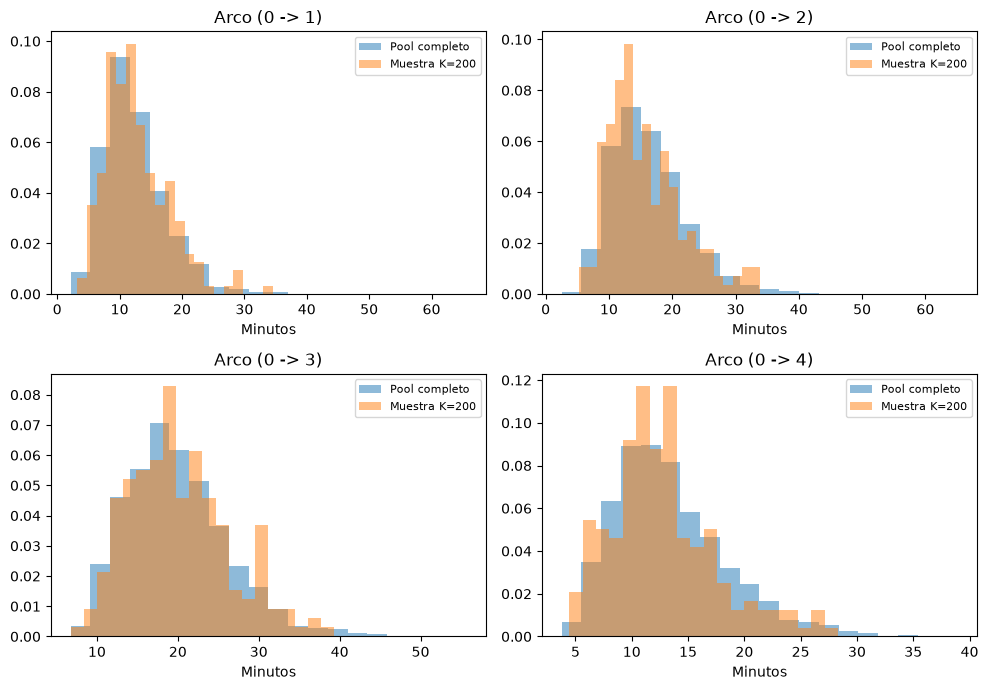

In [8]:
example_arcs = arc_list[:4]  # ajustar a arcos de interés real una vez se revisen resultados

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (i, j) in zip(axes.flat, example_arcs):
    pool_vals = pools_dict[(i, j)]
    sample_vals = scenarios_K200[f"xi_{i}_{j}"].to_numpy()
    ax.hist(pool_vals, bins=20, alpha=0.5, density=True, label="Pool completo")
    ax.hist(sample_vals, bins=20, alpha=0.5, density=True, label="Muestra K=200")
    ax.set_title(f"Arco ({i} -> {j})")
    ax.set_xlabel("Minutos")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 8. Guardar escenarios

In [9]:
scenarios_K50.to_parquet(PROC_DIR / "scenarios_K50.parquet", index=False)
scenarios_K200.to_parquet(PROC_DIR / "scenarios_K200.parquet", index=False)

# Guardamos también el orden de arcos usado, para que los notebooks de modelado
# lo carguen en vez de reconstruirlo (evita inconsistencias de orden de columnas).
arc_order = pd.DataFrame(arc_list, columns=["i", "j"])
arc_order.to_csv(PROC_DIR / "arc_order.csv", index=False)

print("Guardado:")
print(f"  {PROC_DIR / 'scenarios_K50.parquet'}   {scenarios_K50.shape}")
print(f"  {PROC_DIR / 'scenarios_K200.parquet'}  {scenarios_K200.shape}")
print(f"  {PROC_DIR / 'arc_order.csv'}           {arc_order.shape}")


Guardado:
  ../data/processed/scenarios_K50.parquet   (50, 110)
  ../data/processed/scenarios_K200.parquet  (200, 110)
  ../data/processed/arc_order.csv           (110, 2)
